#### Libraries

In [8]:
# Prevent OpenMP runtime conflict between libraries like PyTorch, TensorFlow, and NumPy on Windows
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.append(os.path.abspath(".."))

from libraries import torch, nn, optim, Accuracy, DataLoader, plt

#### Load variables

In [2]:
vars = torch.load('../saved_values/variables.pt', weights_only=False)
train_dataset = vars['train_dataset']
valid_loader = vars['valid_loader']

#### Utils

In [3]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

#### MLP model with layers: 2, 3, 4

In [4]:
def multi_layer_model(num_layer):
    """Initialize mlp model with different layers"""
    in_features = 12
    out_features = 1
    h1 = 64
    h2 = 32
    h3 = 16
    h4 = 8

    if num_layer == 2:
        model = nn.Sequential(nn.Linear(in_features, h1),
                            nn.ReLU(),
                            nn.Linear(h1, h2),
                            nn.ReLU(),
                            nn.Linear(h2, out_features),
                            nn.Sigmoid())
        return model

    elif num_layer == 3:
        model = nn.Sequential(nn.Linear(in_features, h1),
                            nn.ReLU(),
                            nn.Linear(h1, h2),
                            nn.ReLU(),
                            nn.Linear(h2, h3),
                            nn.ReLU(),
                            nn.Linear(h3, out_features),
                            nn.Sigmoid())
        return model
    
    elif num_layer == 4:
        model = nn.Sequential(nn.Linear(in_features, h1),
                        nn.ReLU(),
                        nn.Linear(h1, h2),
                        nn.ReLU(),
                        nn.Linear(h2, h3),
                        nn.ReLU(),
                        nn.Linear(h3, h4),
                        nn.ReLU(),
                        nn.Linear(h4, out_features),
                        nn.Sigmoid())
        return model

#### Train model for different number of hidden layers: 2, 3, 4

In [5]:
loss_train_hist = []
loss_valid_hist = []

acc_train_hist = []
acc_valid_hist = []

num_epochs = 600
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
loss_fn = nn.BCELoss()

for num_layer in [2, 3, 4]:
    model = multi_layer_model(num_layer)
    optimizer = optim.SGD(model.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        loss_train = AverageMeter()
        acc_train = Accuracy(task='binary')
        
        for inputs, targets in train_loader:
            outputs = model(inputs)
            loss = loss_fn(outputs.squeeze(), targets)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            loss_train.update(loss.item())
            acc_train(outputs.squeeze(), targets)

        loss_train_hist.append(loss_train.avg)
        acc_train_hist.append(acc_train.compute())

    
        with torch.no_grad():
            loss_valid = AverageMeter()
            acc_valid = Accuracy(task='binary')
            
            for inputs, targets in valid_loader:
                outputs = model(inputs)
                loss = loss_fn(outputs.squeeze(), targets)

                outputs = model(inputs)
                loss = loss_fn(outputs.squeeze(), targets)

                loss_valid.update(loss.item())
                acc_valid(outputs.squeeze(), targets)

        loss_valid_hist.append(loss_valid.avg)
        acc_valid_hist.append(acc_valid.compute())

    
        if epoch % 10 == 0:
            print(f'Epoch: {epoch} | Number of Layers: {num_layer}')
            print(f'\tTrain Loss: {loss_train.avg:.4f} | Train Accuracy: {acc_train.compute():.4f}')
            print(f'\tValidation Loss: {loss_valid.avg:.4f} | Validation Accuracy: {acc_valid.compute():.4f}\n')
    

Epoch: 0 | Number of Layers: 2
	Train Loss: 0.7200 | Train Accuracy: 0.3116
	Validation Loss: 0.7162 | Validation Accuracy: 0.3417

Epoch: 10 | Number of Layers: 2
	Train Loss: 0.6694 | Train Accuracy: 0.6784
	Validation Loss: 0.6676 | Validation Accuracy: 0.6834

Epoch: 20 | Number of Layers: 2
	Train Loss: 0.6395 | Train Accuracy: 0.6884
	Validation Loss: 0.6379 | Validation Accuracy: 0.6834

Epoch: 30 | Number of Layers: 2
	Train Loss: 0.6179 | Train Accuracy: 0.6834
	Validation Loss: 0.6163 | Validation Accuracy: 0.6834

Epoch: 40 | Number of Layers: 2
	Train Loss: 0.5996 | Train Accuracy: 0.6834
	Validation Loss: 0.5981 | Validation Accuracy: 0.6834

Epoch: 50 | Number of Layers: 2
	Train Loss: 0.5832 | Train Accuracy: 0.6834
	Validation Loss: 0.5819 | Validation Accuracy: 0.6834

Epoch: 60 | Number of Layers: 2
	Train Loss: 0.5669 | Train Accuracy: 0.6884
	Validation Loss: 0.5665 | Validation Accuracy: 0.6884

Epoch: 70 | Number of Layers: 2
	Train Loss: 0.5516 | Train Accuracy: 

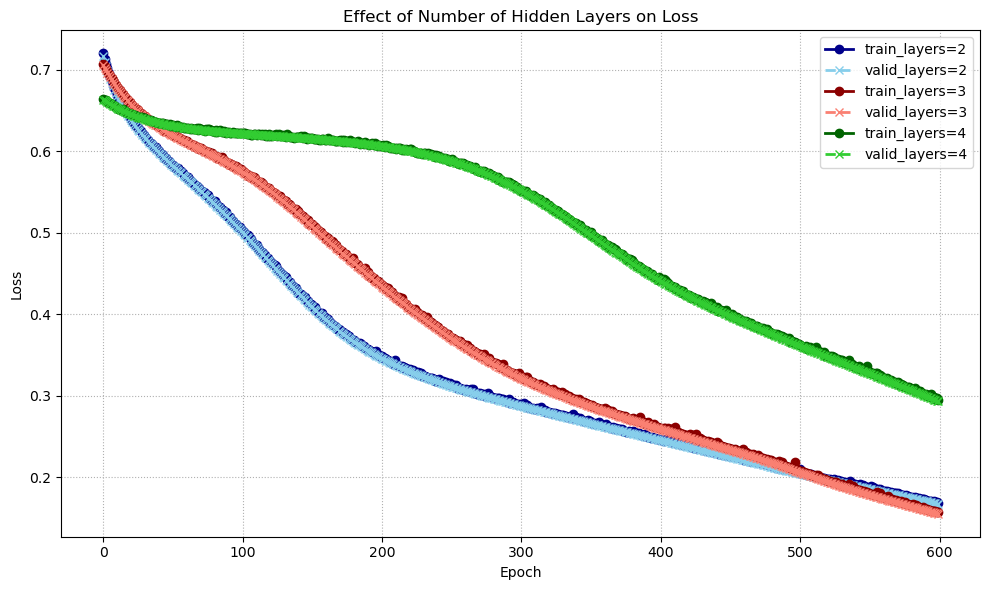

In [9]:
plt.figure(figsize=(10,6))

colors = ['darkblue', 'darkred', 'darkgreen']
light_colors = ['skyblue', 'salmon', 'limegreen']
layers = [2, 3, 4]

for i, num_layer in enumerate(layers):

    start = i * num_epochs
    end = (i + 1) * num_epochs

    # Train Loss
    plt.plot(
        range(num_epochs),
        loss_train_hist[start:end],
        color=colors[i],
        linewidth=2,
        marker='o',
        label=f'train_layers={num_layer}'
    )

    # Validation Loss
    plt.plot(
        range(num_epochs),
        loss_valid_hist[start:end],
        color=light_colors[i],
        linewidth=2,
        linestyle='--',
        marker='x',
        label=f'valid_layers={num_layer}'
    )

plt.title("Effect of Number of Hidden Layers on Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()

plt.show()